# Анализ лояльности пользователей Яндекс Афиши с помощью Python

Команда маркетинга хочет лучше понимать поведение пользователей.

Нужно провести исследовательский анализ данных, чтобы понять, какие пользователи с большей вероятностью возвращаются на платформу и делают заказы повторно.

## Выгрузка из базы данных SQL должна создержать:

- `user_id` — уникальный идентификатор пользователя, совершившего заказ;
- `device_type_canonical` — тип устройства, с которого был оформлен заказ ( mobile — мобильные устройства, desktop — стационарные);
- `order_id` — уникальный идентификатор заказа;
- `order_dt` — дата создания заказа (используйте данные created_dt_msk );
- `order_ts` — дата и время создания заказа (используйте данные created_ts_msk );
- `currency_code` — валюта оплаты;
- `revenue` — выручка от заказа;
- `tickets_count` — количество купленных билетов;
- `days_since_prev` — количество дней от предыдущей покупки пользователя, для пользователей с одной покупкой — значение пропущено;
- `event_id` — уникальный идентификатор мероприятия;
- `service_name` — название билетного оператора;
- `event_type_main` — основной тип мероприятия (театральная постановка, концерт и так далее);
- `region_name` — название региона, в котором прошло мероприятие;
- `city_name` — название города, в котором прошло мероприятие.


## Загрузка данных


In [1]:
import pandas as pd
import numpy as np

# Загружаем библиотеки для визуализации данных
import matplotlib.pyplot as plt
import seaborn as sns

# Загружаем библиотеку для корреляции
from phik import phik_matrix

# Загружаем библиотеку для работы с переменными окружения
from dotenv import load_dotenv
from sqlalchemy import create_engine
import os

In [2]:
load_dotenv()

db_config = {
    'user': os.getenv('DB_USER'),
    'pwd': os.getenv('DB_PASSWORD'), 
    'host': os.getenv('DB_HOST'),
    'port': int(os.getenv('DB_PORT')),
    'db': os.getenv('DB_NAME')
}

In [3]:
connection_string = 'postgresql://{}:{}@{}:{}/{}'.format(
    db_config['user'],
    db_config['pwd'],
    db_config['host'],
    db_config['port'],
    db_config['db'],
)

In [4]:
engine = create_engine(connection_string)

In [5]:
query = '''
SELECT
	user_id,
	device_type_canonical,
	order_id,
	created_dt_msk as order_dt,
	created_ts_msk as order_ts,
	currency_code,
	revenue,
	tickets_count,
	-- Count number of days since last order. 
	-- The result must be a numeric
	EXTRACT(DAY FROM created_dt_msk - LAG(created_dt_msk) OVER (PARTITION BY user_id ORDER BY created_dt_msk)) AS days_since_prev,
	event_id,
	event_name_code AS event_name,
	event_type_main,
	service_name,
	region_name,
	city_name
FROM afisha.purchases p
JOIN afisha.events e USING(event_id)
JOIN afisha.city c USING(city_id)
JOIN afisha.regions r USING(region_id)
WHERE (device_type_canonical IN ('mobile', 'desktop')) AND (event_type_main != 'фильм')
ORDER BY user_id, order_ts
'''

In [6]:
df = pd.read_sql_query(query, con=engine)

## Анализ данных


In [7]:
# Выводим 5 рандомных значений для анализа
df.sample(5, random_state=42)

,user_id,device_type_canonical,order_id,order_dt,order_ts,currency_code,revenue,tickets_count,days_since_prev,event_id,event_name,event_type_main,service_name,region_name,city_name
195464,a3465bb7f920908,mobile,6943645,2024-10-25,2024-10-25 17:59:18,rub,551.38,4,0.0,174876,c0e9358b-581c-461b-bb70-adf877affb18,другое,Мой билет,Широковская область,Луговаярово
287418,fe237d2cfd6e503,desktop,6018197,2024-07-22,2024-07-22 12:22:34,rub,0.00,1,0.0,537806,102fa659-6ca3-4a78-a0a4-20a0339679b5,другое,Билеты без проблем,Каменевский регион,Глиногорск
42929,1a1514f0360ff18,mobile,4063597,2024-09-29,2024-09-29 10:56:08,rub,68.63,4,0.0,566686,3cae43c4-d28c-4a5b-a623-0037ebf2729a,другое,Лови билет!,Речиновская область,Дальнесветск
142669,75c7893ea1eb7ef,mobile,6827587,2024-09-21,2024-09-21 14:31:17,rub,243.78,2,0.0,14893,22af6c33-aaa7-43cf-90c8-03e6faec9afa,театр,Лучшие билеты,Яблоневская область,Светополье
179797,9256ac0cd3dd438,desktop,2485591,2024-10-31,2024-10-31 22:17:57,rub,41.83,1,0.0,589624,c9eb1fa4-257b-4290-975a-7fe34b46d11b,концерты,Мой билет,Каменевский регион,Глиногорск


In [8]:
# Запоминаем категорияальные ячейки, чтобы их выводить
category_cols = ['device_type_canonical', 'currency_code', 'event_type_main', 'service_name', 'region_name', 'city_name']

In [9]:
# Запоминаем числовые ячейки
num_cols = ['revenue', 'tickets_count', 'days_since_prev']

In [10]:
# Запомним значения, которые являются id
id_cols = ['user_id', 'order_id', 'event_id', 'event_name']

In [11]:
# Запомним значения, которые являются датами
date_cols = ['order_dt', 'order_ts']

In [12]:
start_df_size = df.shape[0]

In [13]:
df.shape

(290611, 15)

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 290611 entries, 0 to 290610
Data columns (total 15 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   user_id                290611 non-null  object        
 1   device_type_canonical  290611 non-null  object        
 2   order_id               290611 non-null  int64         
 3   order_dt               290611 non-null  datetime64[ns]
 4   order_ts               290611 non-null  datetime64[ns]
 5   currency_code          290611 non-null  object        
 6   revenue                290611 non-null  float64       
 7   tickets_count          290611 non-null  int64         
 8   days_since_prev        268678 non-null  float64       
 9   event_id               290611 non-null  int64         
 10  event_name             290611 non-null  object        
 11  event_type_main        290611 non-null  object        
 12  service_name           290611 non-null  obje

In [15]:
# Вывод доли пропусков
empty = df.isna().mean() * 100
# Вывод только колонок где пропуски есть
empty.loc[empty > 0]

days_since_prev    7.547202
dtype: float64

### Промежуточный вывод


**Названия колонок**

Названия клонок в snake_case нотоации и не нуждаются в нормализации


**Типы колонок**

Все типы данных соответсвтуют ожиданиям.
Стоит изменить размерность


In [16]:
# Выводим категориальные колонки
print('Категориальные колонки:', ', '.join(category_cols))

Категориальные колонки: device_type_canonical, currency_code, event_type_main, service_name, region_name, city_name


In [17]:
print('Числовые колонки:', ', '.join(num_cols))

Числовые колонки: revenue, tickets_count, days_since_prev


In [18]:
print('ID колонки:', ', '.join(id_cols))

ID колонки: user_id, order_id, event_id, event_name


In [19]:
print('Dates колонки:', ', '.join(date_cols))

Dates колонки: order_dt, order_ts


**Пропуски**

Пропуски нашлись в одной колонке, ее 0 в ней - это валидное значение.

Значит что было 2 заказа в 1 день. Null - это пропуск, означает что был всего 1 заказ


In [20]:
empty.loc[empty > 0]

days_since_prev    7.547202
dtype: float64

**Размер исходного df**


In [21]:
print(f'Количество строк: {df.shape[0]}') 
print(f'Количество колонок: {df.shape[1]}')

Количество строк: 290611
Количество колонок: 15


## Предобработка данных

- оценка явных и неявных дубликатов в данных
- оценка количественных значений, выбросы


### Преобразование revenue к одной валюте.

Создаем новую колонку `revenue_rub`, где будет храниться выручка только в рублях


In [22]:
## Загружаем курс тенге
tenge_exchange_df = pd.read_csv('../data/proceed/final_tickets_tenge_df.csv')

In [23]:
## Проверяем что в датасете нет пропусков и сколько значений
tenge_exchange_df.info();

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 357 entries, 0 to 356
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   data     357 non-null    object 
 1   nominal  357 non-null    int64  
 2   curs     357 non-null    float64
 3   cdx      357 non-null    object 
dtypes: float64(1), int64(1), object(2)
memory usage: 11.3+ KB


In [24]:
## смотрим структуру данных
## Представлен курс казахского тенге к рублю на каждый день
## Для проверки: за 100 рублей (nominal) дают 19 (curs) тенге
## Поставим индекс на дату, чтобы проще было искать
## Преобразуем в фомате datetime, чтобы соответствовал order_dt формата: 2024-10-31 00:00:00
tenge_exchange_df = tenge_exchange_df.set_index('data').sort_index()
tenge_exchange_df.index = pd.to_datetime(tenge_exchange_df.index)


In [25]:
tenge_exchange_df.sample(3, random_state=42)

,nominal,curs,cdx
data,,,
2024-08-19,100,18.5775,kzt
2024-02-21,100,20.5156,kzt
2024-10-27,100,19.9266,kzt


In [26]:
## Создадим колонку revenue_rub, со значениями revenue в рублях

def convert_kzt_to_rub(value, date):
    # находим курс тенге по дате
    try:
        rate = tenge_exchange_df.loc[date, 'curs']
        nominal = tenge_exchange_df.loc[date, 'nominal']
        return round((value / nominal) * rate, 2)
    except:
        return np.nan
    

def normalize_currency(row):
    # Если данные в рублях, то оставляем как есть, если в тенге, то конвертируем
    if row['currency_code'] == 'rub':
        return row['revenue']
    elif row['currency_code'] == 'kzt':
        # округляем до 2-х знаков после запятой
        return convert_kzt_to_rub(row['revenue'], row['order_dt'])
    else:
       return np.nan

## Создадим колонку revenue_rub, со значениями revenue в рублях
df['revenue_rub'] = df[['currency_code', 'revenue', 'order_dt']].apply(normalize_currency, axis=1)

In [27]:
# Проверяем себя, что преобразование сделано и оно верное. 
# Я решил не округлять - но в будущем преобразовать тип данных
df[df['currency_code']  == 'kzt'].head(3)

,user_id,device_type_canonical,order_id,order_dt,order_ts,currency_code,revenue,tickets_count,days_since_prev,event_id,event_name,event_type_main,service_name,region_name,city_name,revenue_rub
70,0033403583a55ed,mobile,7850214,2024-09-17,2024-09-17 16:52:06,kzt,518.10,4,20.0,559919,f5ec2467-ee48-42f3-89a0-a2d90d1d6fce,другое,Билеты без проблем,Верхоречная область,Серебрянка,98.50
89,0040e12d70fae81,desktop,8634925,2024-09-02,2024-09-02 19:49:14,kzt,347.18,3,39.0,559476,61ec7c0e-ea0c-4a3e-a63a-09cbe1bc6177,другое,Билеты без проблем,Верхоречная область,Серебрянка,65.73
96,0054b38b2653e6e,mobile,7625522,2024-09-09,2024-09-09 18:06:04,kzt,328.77,4,NaN,559582,524f434e-0381-4f47-9688-7c4e41961b65,другое,Билеты без проблем,Верхоречная область,Серебрянка,61.15


In [28]:
# У нас появилась новая количественная колонка 'revenue_rub' и дальше оценивать мы будем ее, а не 'revenue'
num_cols[num_cols.index('revenue')] = 'revenue_rub'

### Проверка категориальных данных

- Смотрим явные дубликаты в данных


In [29]:
## Вывод уникальных значений категориальных данных
for column in category_cols: 
	unique_vals = df[column].sort_values().unique() 
	print(f'Столбец "{column}" — {len(unique_vals)} уникальных значений:') 
	print(', '.join(map(str, unique_vals))) 
	print()

Столбец "device_type_canonical" — 2 уникальных значений:
desktop, mobile

Столбец "currency_code" — 2 уникальных значений:
kzt, rub

Столбец "event_type_main" — 7 уникальных значений:
выставки, другое, концерты, спорт, стендап, театр, ёлки

Столбец "service_name" — 36 уникальных значений:
Crazy ticket!, Show_ticket, Билет по телефону, Билеты без проблем, Билеты в интернете, Билеты в руки, Быстробилет, Быстрый кассир, Весь в билетах, Восьмёрка, Вперёд!, Выступления.ру, Городской дом культуры, Дом культуры, Дырокол, За билетом!, Зе Бест!, КарандашРУ, Кино билет, Край билетов, Лимоны, Лови билет!, Лучшие билеты, Мир касс, Мой билет, Облачко, Прачечная, Радио ticket, Реестр, Росбилет, Тебе билет!, Телебилет, Тех билет, Цвет и билет, Шоу начинается!, Яблоко

Столбец "region_name" — 81 уникальных значений:
Белоярская область, Берестовский округ, Берёзовская область, Боровлянский край, Верховинская область, Верхозёрский край, Верхоречная область, Ветренский регион, Вишнёвский край, Глиногорск

**Промежуточный вывод**

По визуальному анализу категориальных данных - явных дубликатов не найдено.


### Проверка количественных данных

- Смотрим describe
- Строит гистограммы и boxplot


In [30]:
# Количественные данные у нас представлены
print('Количественные колонки:', ', '.join(num_cols))

Количественные колонки: revenue_rub, tickets_count, days_since_prev


In [31]:
# Проверим значения в количественных колонках
for column in num_cols:
    print(f'Значения в {column}:')
    print(df[column].describe())
    print()

Значения в revenue_rub:
count    290611.000000
mean        555.571989
std         875.498170
min         -90.760000
25%         113.970000
50%         351.140000
75%         802.050000
max       81174.540000
Name: revenue_rub, dtype: float64

Значения в tickets_count:
count    290611.000000
mean          2.754311
std           1.170620
min           1.000000
25%           2.000000
50%           3.000000
75%           4.000000
max          57.000000
Name: tickets_count, dtype: float64

Значения в days_since_prev:
count    268678.000000
mean          3.222381
std          11.350509
min           0.000000
25%           0.000000
50%           0.000000
75%           1.000000
max         148.000000
Name: days_since_prev, dtype: float64



Видим большые выбросы у всех значений.
Можно предопложить, что revenue и tickets_count могут быть зависимы. Чем больше билетов - тем больше выручка.

У выручки видим отрицательные значения - возможно возвраты


In [32]:
# Заполнение пропусков в days_since_prev
# Поскольку 0 у нас валидное число и пропусков 7.5%, то для оценики распределения заполним их заглушкой в -1
# заменяет в столбце column NaN на 0
df['days_since_prev'] = df['days_since_prev'].fillna(-1)

In [33]:
## Функция для вывода KDE и boxplot
def plot_numeric_kde_box(df, columns):
    """
    Строит KDE и boxplot для каждой числовой колонки.
    """

    for column in columns:
        data = df[column].dropna()

        fig, axes = plt.subplots(1, 2, figsize=(14, 4))

        # --- KDE ---
        sns.histplot(data=data, ax=axes[0], fill=True)
        axes[0].set_title(f'KDE распределение: {column}')
        axes[0].set_xlabel(column)
        axes[0].set_ylabel('Density')

        # --- Boxplot ---
        sns.boxplot(y=data, ax=axes[1])
        axes[1].set_title(f'Boxplot: {column}')
        axes[1].set_ylabel(column)

        plt.tight_layout()
        plt.show()

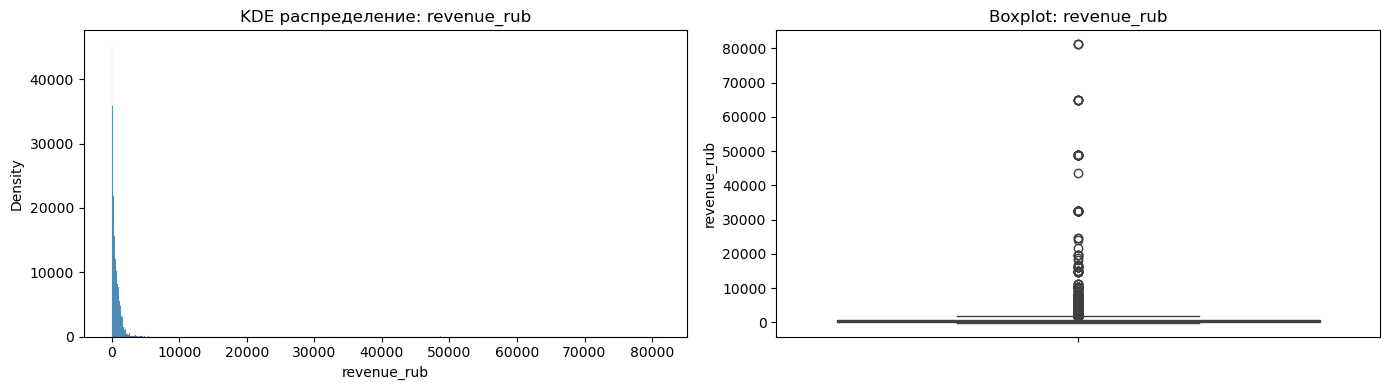

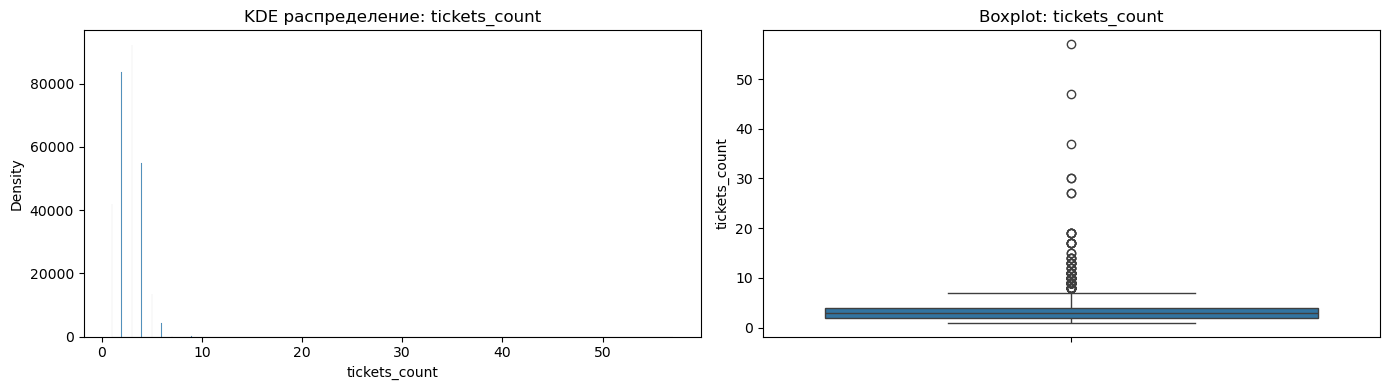

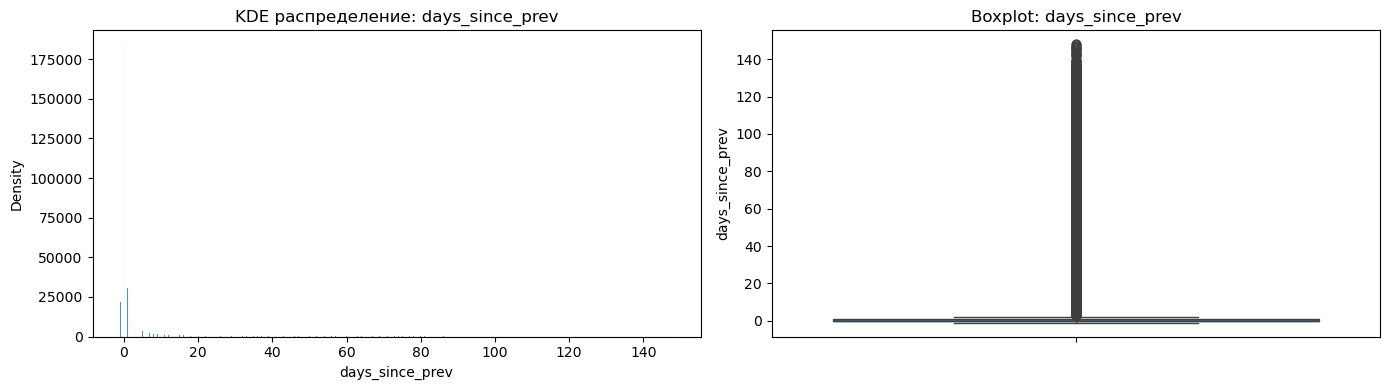

In [34]:
## Выводим boxplot и распределение числовых колонок
plot_numeric_kde_box(
    df,
    num_cols
)

Видим что у нас очень сильно смещены гистограммы влево. На boxplot также сильные выбросы.

75% людей покупают 4 билета. А Max - 57. Можно предположить, что это корпоративные закупки или школы. Поэтому попробуем исключить выбросы.
Попробуем подобрать перцентиль, чтобы убрать выбросы, но оставить большую часть датасета


In [35]:
def check_outliers(df, columns, percentile=0.99):
    """
    Оценка количества выбросов выше заданного перцентиля.

    df: DataFrame
    columns: list[str] — список числовых колонок
    percentile: float — например 0.99, 0.95, 0.995
    """

    for column in columns:
        data = df[column].dropna()
        threshold = data.quantile(percentile)

        count = (data > threshold).sum()
        share = (data > threshold).mean()

        print(f"\nКолонка: {column}")
        print(f"{int(percentile*100)}-й перцентиль: {threshold:,.2f}")
        print(f"Количество значений выше: {count}")
        print(f"Доля: {share*100:.3f}%")

In [36]:
# Пытаемся найти баланс - при каком перцентиле останется максимум значений, но без явных выбросов
check_outliers(df, num_cols, percentile=0.99)


Колонка: revenue_rub
99-й перцентиль: 2,628.42
Количество значений выше: 2825
Доля: 0.972%

Колонка: tickets_count
99-й перцентиль: 6.00
Количество значений выше: 188
Доля: 0.065%

Колонка: days_since_prev
99-й перцентиль: 61.00
Количество значений выше: 2817
Доля: 0.969%


Поскольку мы ищем вернувшихся, пользователей, то метрика days_since_prev является ключевой и нам стоит убрать из нее выбросы


In [37]:
def filter_by_percentiles(df, percentiles_dict):
    """
    Фильтрация датафрейма по разным перцентилям для разных колонок.
    ВАЖНО: Если в данных есть пропуски - то эта функция их отфильрует
    percentiles_dict: dict
        пример:
        {
            'tickets_count': 0.99,
            'revenue_rub': 0.995
        }
    """
    df_filtered = df.copy()
    for column, percentile in percentiles_dict.items():
        threshold = df_filtered[column].quantile(percentile)
        df_filtered = df_filtered[df_filtered[column] <= threshold]
        print(f"{column}: порог {int(percentile*100)}% = {threshold:,.2f}")
    
    original_len = len(df)
    filtered_len = len(df_filtered)
    removed = original_len - filtered_len
    removed_pct = removed / original_len * 100

    print(f"\nИсходный размер:   {original_len:,}")
    print(f"После фильтрации:  {filtered_len:,}")
    print(f"Удалено строк:     {removed:,} ({removed_pct:.2f}%)")
    
    return df_filtered

In [38]:
percentiles = {
    'revenue_rub': 0.99,
    'tickets_count': 0.99,
    'days_since_prev': 0.97
}

df = filter_by_percentiles(df, percentiles)

revenue_rub: порог 99% = 2,628.42
tickets_count: порог 99% = 6.00
days_since_prev: порог 97% = 28.00

Исходный размер:   290,611
После фильтрации:  279,157
Удалено строк:     11,454 (3.94%)


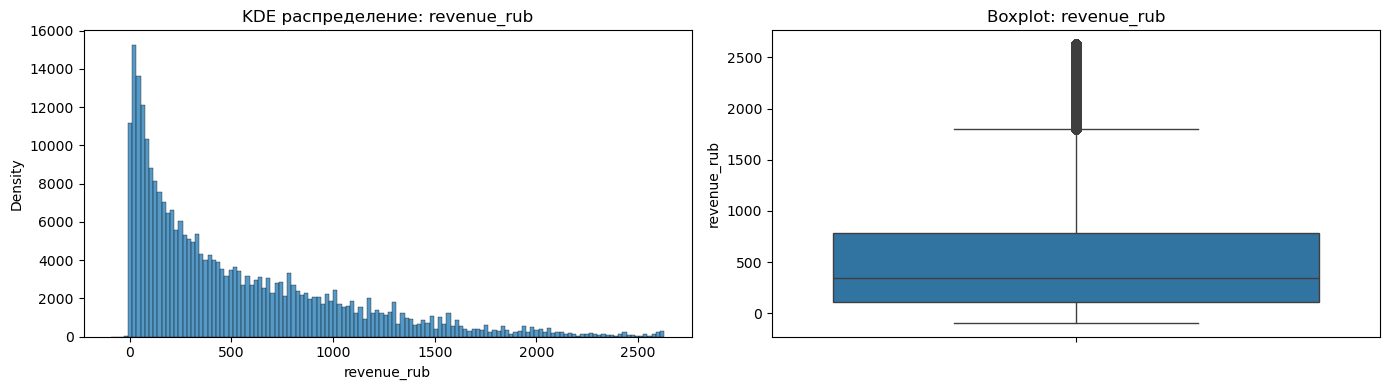

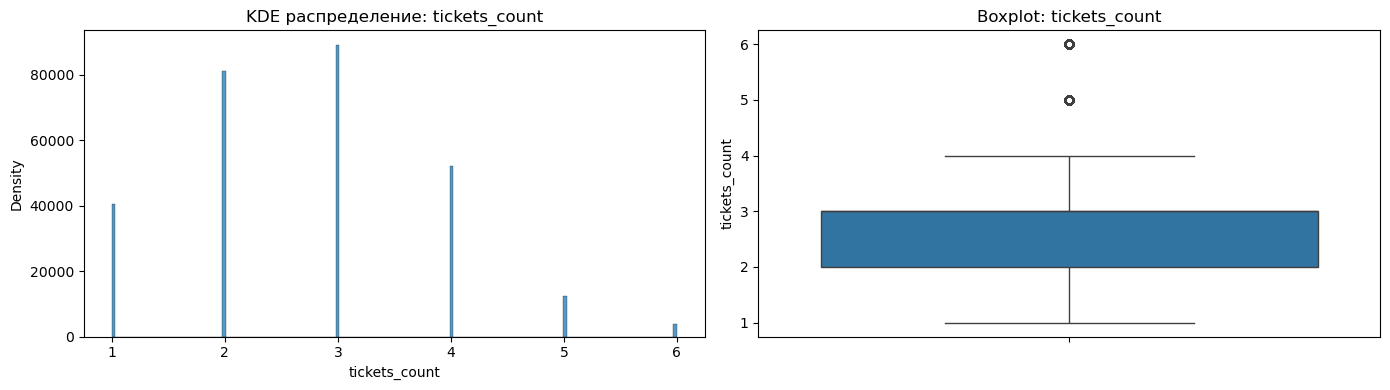

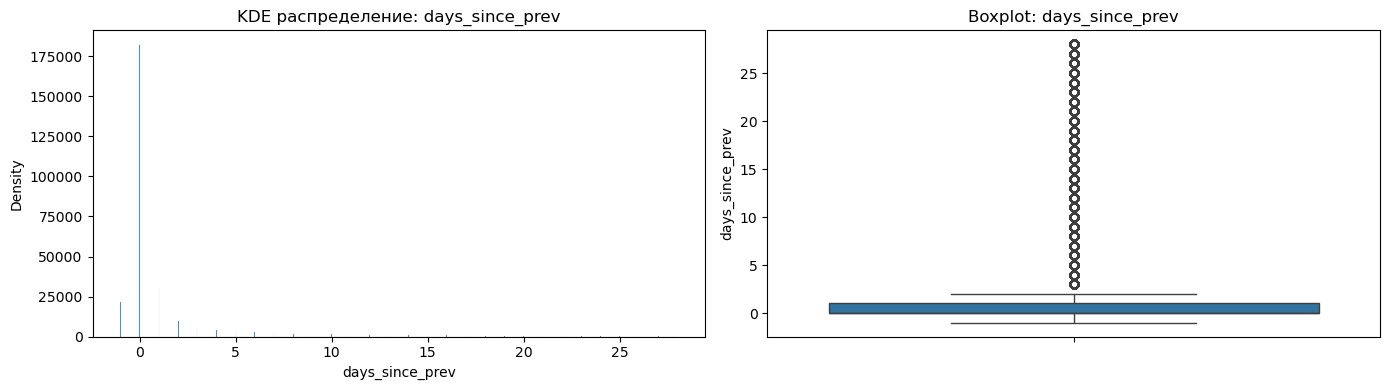

In [39]:
## Смотрим распределение после фильтрации
plot_numeric_kde_box(
    df,
    num_cols
)

In [40]:
# Проверим значения в количественных колонках
for column in num_cols:
    print(f'Значения в {column}:')
    print(df[column].describe())
    print()

Значения в revenue_rub:
count    279157.000000
mean        516.884938
std         511.969912
min         -90.760000
25%         111.050000
50%         342.630000
75%         787.030000
max        2628.420000
Name: revenue_rub, dtype: float64

Значения в tickets_count:
count    279157.000000
mean          2.734970
std           1.135992
min           1.000000
25%           2.000000
50%           3.000000
75%           3.000000
max           6.000000
Name: tickets_count, dtype: float64

Значения в days_since_prev:
count    279157.000000
mean          1.287892
std           3.920775
min          -1.000000
25%           0.000000
50%           0.000000
75%           1.000000
max          28.000000
Name: days_since_prev, dtype: float64



Мы удалили 3.96% от датасеты, пока в пределах допустимого.
Но выбрасы теперь гораздо меньше.


**Преобразование типов данных**

На наших объемах данных это не так важно, но стоит потренироваться.

- days_since_prev можно перевести в int и уменьшить разрядность. Float он был из-за NaN значений
- tickets_count можно уменьшить разрядность, у нам максимум 6
- revenue_rub - поскольку это деньги, то лучше оставить большую точность с float, но уменьшим разрядность


In [41]:
# Осматриваем какие значения сейчас
df[num_cols].sample(3, random_state=42)

,revenue_rub,tickets_count,days_since_prev
145826,486.77,4,-1.0
270674,1896.02,3,15.0
145831,499.24,4,0.0


In [42]:
# Осматриваем какой тип данных сейчас
df[num_cols].info()

<class 'pandas.core.frame.DataFrame'>
Index: 279157 entries, 0 to 290610
Data columns (total 3 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   revenue_rub      279157 non-null  float64
 1   tickets_count    279157 non-null  int64  
 2   days_since_prev  279157 non-null  float64
dtypes: float64(2), int64(1)
memory usage: 8.5 MB


In [43]:
# Меняем тип данных с помощью цикла
for column in ['days_since_prev', 'tickets_count']:
    df[column] = pd.to_numeric(df[column], errors='coerce', downcast='integer') 

In [44]:
# Меняем тип данных с помощью цикла
for column in ['revenue_rub']:
    df[column] = pd.to_numeric(df[column], errors='coerce', downcast='float') 

In [45]:
# Осматриваем какой тип данных сейчас
df[num_cols].info()

<class 'pandas.core.frame.DataFrame'>
Index: 279157 entries, 0 to 290610
Data columns (total 3 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   revenue_rub      279157 non-null  float32
 1   tickets_count    279157 non-null  int8   
 2   days_since_prev  279157 non-null  int8   
dtypes: float32(1), int8(2)
memory usage: 3.7 MB


**Промежуточные выводы**

В результате преобразования количественных данных было удалено 11,454 (3.94%) строк

В датасете осталось 279,157 строк

days_since_prev - пропуски были заменены заглушкой -1

Преобразование типов:

- revenue_rub - float32
- tickets_count - int8
- days_since_prev - int8


### Проверка полей с датой

- Оценить диапазон min / max дат
- Посмотриеть сколько в каждом месяце значений
- Даты уже в нужно формате, поэтому в преобразовании не нуждаются


In [46]:
df[date_cols].describe()

,order_dt,order_ts
count,279157,279157
mean,2024-09-01 14:39:21.329287680,2024-09-02 05:33:46.835364864
min,2024-06-01 00:00:00,2024-06-01 00:00:42
25%,2024-07-29 00:00:00,2024-07-29 15:13:57
50%,2024-09-12 00:00:00,2024-09-12 09:33:29
75%,2024-10-09 00:00:00,2024-10-09 13:57:56
max,2024-10-31 00:00:00,2024-10-31 23:59:54


In [47]:
# Сгруппируем данные по месяцам,
# Выбираем колонку по которой будем группировать
col = 'order_dt'

In [48]:
df[col].dt.to_period('M').value_counts().sort_index()

order_dt
2024-06    33889
2024-07    39633
2024-08    42949
2024-09    66704
2024-10    95982
Freq: M, Name: count, dtype: int64

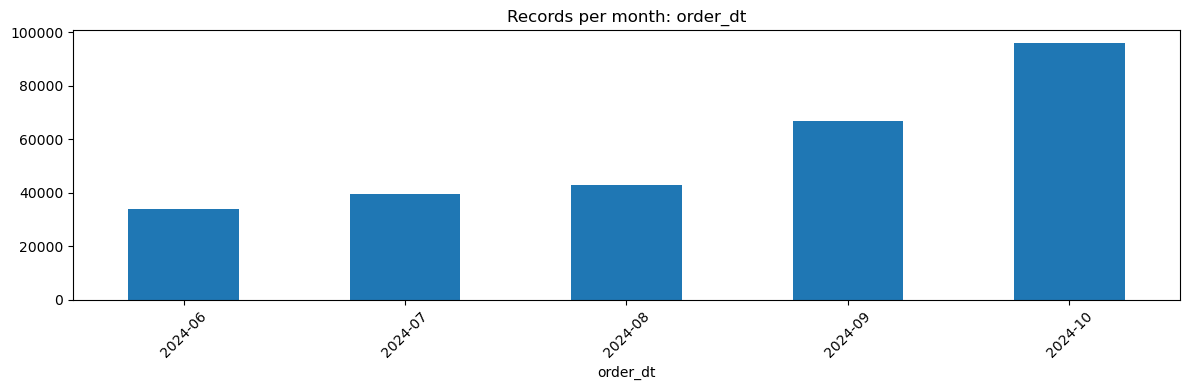

In [49]:
monthly = df[col].dt.to_period('M').value_counts().sort_index()

monthly.plot(kind='bar', figsize=(12, 4), title=f'Records per month: {col}')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Видно что данные представлены за 5 месяцев, с 2024-06-01 по 2024-10-31

Никаких преобразований не делали - просто оценили датасет


### Обработка неявных дубликатов

- Определик колонки, которые бы сказали - что это дубликат.
- Оценим визуально
- Дубликаты удалим


In [50]:
# колонки, которые могут быть дубликатами
dublicate_cols = ['user_id', 'order_ts', 'event_name', 'revenue']
# keep=False — помечает ВСЕ строки (и оригинал и дубликат)
print("Найдено неявных дубликатов:")
df.duplicated(subset=dublicate_cols, keep=False).sum()

Найдено неявных дубликатов:


np.int64(91)

In [51]:
# keep=False — помечает ВСЕ строки (и оригинал и дубликат)
all_dups = df[df.duplicated(subset=dublicate_cols, keep=False)]
all_dups.sort_values(by=dublicate_cols)

,user_id,device_type_canonical,order_id,order_dt,order_ts,currency_code,revenue,tickets_count,days_since_prev,event_id,event_name,event_type_main,service_name,region_name,city_name,revenue_rub
11761,06eb7897f65b433,mobile,1123983,2024-08-13,2024-08-13 16:31:07,rub,69.82,1,0,183706,69796237-909b-42a7-bfb5-c1b8574c4c76,театр,Билеты в руки,Светополянский округ,Глиноград,69.820000
11762,06eb7897f65b433,mobile,1123867,2024-08-13,2024-08-13 16:31:07,rub,69.82,1,0,183706,69796237-909b-42a7-bfb5-c1b8574c4c76,театр,Билеты в руки,Светополянский округ,Глиноград,69.820000
12675,08199117318954f,desktop,5592970,2024-07-31,2024-07-31 11:52:06,rub,0.00,3,0,553623,8aa79719-8122-4b50-ae2a-fa484d034c5c,другое,Билеты без проблем,Каменевский регион,Глиногорск,0.000000
12676,08199117318954f,mobile,5593202,2024-07-31,2024-07-31 11:52:06,rub,0.00,3,0,553623,8aa79719-8122-4b50-ae2a-fa484d034c5c,другое,Билеты без проблем,Каменевский регион,Глиногорск,0.000000
26877,0dc525d7bacbb0d,desktop,1930705,2024-07-31,2024-07-31 13:26:11,rub,1556.05,3,0,393430,b33d7a0b-a715-47e3-803e-02482884a73e,концерты,Лови билет!,Каменевский регион,Глиногорск,1556.050049
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
285383,fd4d47438ebb946,desktop,8548099,2024-06-19,2024-06-19 15:40:56,rub,989.57,3,0,489843,25a26bf3-cb70-4f37-a7f0-c97cc065d414,театр,Билеты без проблем,Каменевский регион,Глиногорск,989.570007
285384,fd4d47438ebb946,desktop,8547809,2024-06-19,2024-06-19 15:40:56,rub,989.57,3,0,489843,25a26bf3-cb70-4f37-a7f0-c97cc065d414,театр,Билеты без проблем,Каменевский регион,Глиногорск,989.570007
285380,fd4d47438ebb946,desktop,8547983,2024-06-19,2024-06-19 15:40:56,rub,1319.43,4,0,489843,25a26bf3-cb70-4f37-a7f0-c97cc065d414,театр,Билеты без проблем,Каменевский регион,Глиногорск,1319.430054
285381,fd4d47438ebb946,desktop,8548012,2024-06-19,2024-06-19 15:40:56,rub,1319.43,4,0,489843,25a26bf3-cb70-4f37-a7f0-c97cc065d414,театр,Билеты без проблем,Каменевский регион,Глиногорск,1319.430054


Визуальный анализ показал, что дубликаты полные, кроме order_id. Все остальное совпадает, поэтому нужно удалять


In [52]:
## Удаление дубликатов со сбросом индексов
df = df.drop_duplicates().reset_index(drop=True)

**Предвательные выводы**

Найден 91 неявный дубликат, совпадающие по всем полям, кроме order_id.

Дубликаты удалены, индекс сброшен


## Выводы по предобработке данных

**Категориальные данные**

- Добавлено новое поле `revenue_run`, где выводится валюта в рублях. (ковертирована из kzt)
- По визуальному анализу категориальных данных - явных дубликатов не найдено. Данные выглядят корректно

**Колиличественные данные**

В результате преобразования количественных данных было удалено 11,454 (3.94%) строк

В датасете осталось 279,157 строк

days_since_prev - пропуски были заменены заглушкой -1

Преобразование типов:

- revenue_rub - float32
- tickets_count - int8
- days_since_prev - int8

**Данные даты**

Данные представлены за 5 месяцев, с 2024-06-01 по 2024-10-31

Никаких преобразований не делали - просто оценили датасет

**Неявные дубликаты**

Найден 91 неявный дубликат, совпадающие по всем полям, кроме order_id.

Дубликаты удалены, индекс сброшен

**Размер df после предобработки**


In [53]:
print(f'Количество строк: {df.shape[0]}') 
print(f'Количество колонок: {df.shape[1]}')

Количество строк: 279157
Количество колонок: 16


In [54]:
print('Количесто строк удалено по время предобработки:')
start_df_size - df.shape[0]

Количесто строк удалено по время предобработки:


11454

In [55]:
print('% Удаленных данных от всего DF')
round(100 - (df.shape[0] / start_df_size * 100), 2)

% Удаленных данных от всего DF


3.94

## Создание профиля пользователя

В будущем отдел маркетинга планирует создать модель для прогнозирования возврата пользователей. Поэтому сейчас они просят вас построить агрегированные признаки, описывающие поведение и профиль каждого пользователя.


Постройте профиль пользователя — для каждого пользователя найдите:

- дату первого и последнего заказа;
- устройство, с которого был сделан первый заказ;
- регион, в котором был сделан первый заказ;
- билетного партнёра, к которому обращались при первом заказе;
- жанр первого посещённого мероприятия (используйте поле event_type_main );
- общее количество заказов;
- средняя выручка с одного заказа в рублях;
- среднее количество билетов в заказе;
- среднее время между заказами.
  После этого добавьте два бинарных признака:
- is_two — совершил ли пользователь 2 и более заказа;
- is_five — совершил ли пользователь 5 и более заказов.


In [86]:
# Собираем профиль пользователя:
profiles = (df
    # В начале сортируем данные по дате совершения заказа, что найти первые признаки:
    .sort_values(by='order_ts')
    # Затем группируем по номеру пользователя и агрегируем данные:
    .groupby('user_id')
    .agg(
        # Находим первую и последнюю даты заказа:
        first_order_dt=('order_dt','min'),
        last_order_dt=('order_dt','max'),
        # Находим устройства, регион и название билетного партнера первого заказа:
        first_device=('device_type_canonical','first'),
        first_region_name=('region_name','first'),
        first_service_name=('service_name','first'),
        # Жанр первого посещённого мероприятия (event_type_main):
        first_event_type=('event_type_main','first'),
        # Подсчитваем количество заказов:
        total_orders=('order_id','nunique'),
        # Считаем статистику по заказам: средняя стоимость заказа, среднее количество билетов:
        avg_revenue_rub=('revenue_rub','mean'),
        avg_tickets_count=('tickets_count','mean'),
        # Считаем среднее количество дней между покупками:
        avg_days_since_prev=('days_since_prev','mean')
    )
    # Создаем два признака: совершил ли пользователь 2 / 5 и более заказов:
    .assign(
        is_two = lambda x: x['total_orders'] >= 2,
        is_five = lambda x: x['total_orders'] >= 5
    )
)

In [87]:
# Проверяем что все это уникальные user_id
print(f'Количество уникальных пользователей: {df["user_id"].nunique()}')
print(f'Количество уникальных пользователей в новом profiles: {profiles.index.nunique()}')
print(f'Количество количества строк в новом profiles {profiles.shape[0]}')

Количество уникальных пользователей: 21832
Количество уникальных пользователей в новом profiles: 21832
Количество количества строк в новом profiles 21832


In [88]:
profiles.sample(3, random_state=42)

,first_order_dt,last_order_dt,first_device,first_region_name,first_service_name,first_event_type,total_orders,avg_revenue_rub,avg_tickets_count,avg_days_since_prev,is_two,is_five
user_id,,,,,,,,,,,,
944ba13ae32812c,2024-09-30,2024-09-30,mobile,Малиновоярский округ,Облачко,концерты,1,919.750000,3.000000,-1.000000,False,False
dee8771de6229c6,2024-10-04,2024-10-04,mobile,Каменевский регион,За билетом!,другое,3,1103.430054,4.333333,-0.333333,True,False
59d7d5fb6eb4964,2024-09-13,2024-10-16,mobile,Каменевский регион,Прачечная,театр,3,475.596680,3.333333,10.666667,True,False


### Анализируем новый датасет профиля пользователя


In [89]:
# Общее количество строк в профиле пользователей
print(f'Количество строк в профиле пользователей: {profiles.shape[0]}')

Количество строк в профиле пользователей: 21832


In [90]:
# Средняя выручка с одного заказа
print(f'Средняя выручка с одного заказа: {profiles["avg_revenue_rub"].mean():,.2f} руб.')

Средняя выручка с одного заказа: 545.32 руб.


In [91]:
# Доля пользователей совершивших 2 и более заказа
print(f'Доля пользователей, совершивших 2 и более заказа: {profiles["is_two"].mean():,.2f}')

Доля пользователей, совершивших 2 и более заказа: 0.56


In [92]:
# Доля пользователей совершивших 5 и более заказа
print(f'Доля пользователей, совершивших 5 и более заказа: {profiles["is_five"].mean():,.2f}')

Доля пользователей, совершивших 5 и более заказа: 0.26


In [93]:
profiles.sample(5, random_state=42)

,first_order_dt,last_order_dt,first_device,first_region_name,first_service_name,first_event_type,total_orders,avg_revenue_rub,avg_tickets_count,avg_days_since_prev,is_two,is_five
user_id,,,,,,,,,,,,
944ba13ae32812c,2024-09-30,2024-09-30,mobile,Малиновоярский округ,Облачко,концерты,1,919.750000,3.000000,-1.000000,False,False
dee8771de6229c6,2024-10-04,2024-10-04,mobile,Каменевский регион,За билетом!,другое,3,1103.430054,4.333333,-0.333333,True,False
59d7d5fb6eb4964,2024-09-13,2024-10-16,mobile,Каменевский регион,Прачечная,театр,3,475.596680,3.333333,10.666667,True,False
1623a63f9124bab,2024-07-15,2024-10-22,desktop,Лугоградская область,Облачко,концерты,9,1041.004395,3.555556,1.666667,True,True
eeaff3d59820668,2024-06-20,2024-06-20,mobile,Североярская область,Лови билет!,другое,1,7.540000,1.000000,-1.000000,False,False


### Смотрим количественные данные Profiles

- по общему числу заказов;
- по среднему числу билетов в заказе;
- по среднему количеству дней между покупками.


In [94]:
# собираем нужные колонки
pr_num_cols = ['total_orders', 'avg_revenue_rub', 'avg_tickets_count']

In [95]:
# Изука
for column in pr_num_cols:
    print(f'Значения в {column}:')
    print(profiles[column].describe())
    print()

Значения в total_orders:
count    21832.000000
mean        12.786598
std        121.638656
min          1.000000
25%          1.000000
50%          2.000000
75%          5.000000
max      10168.000000
Name: total_orders, dtype: float64

Значения в avg_revenue_rub:
count    21832.000000
mean       545.316223
std        445.881897
min        -10.770000
25%        197.135010
50%        457.359161
75%        772.603165
max       2628.419922
Name: avg_revenue_rub, dtype: float64

Значения в avg_tickets_count:
count    21832.000000
mean         2.737845
std          0.932914
min          1.000000
25%          2.000000
50%          2.750000
75%          3.045996
max          6.000000
Name: avg_tickets_count, dtype: float64



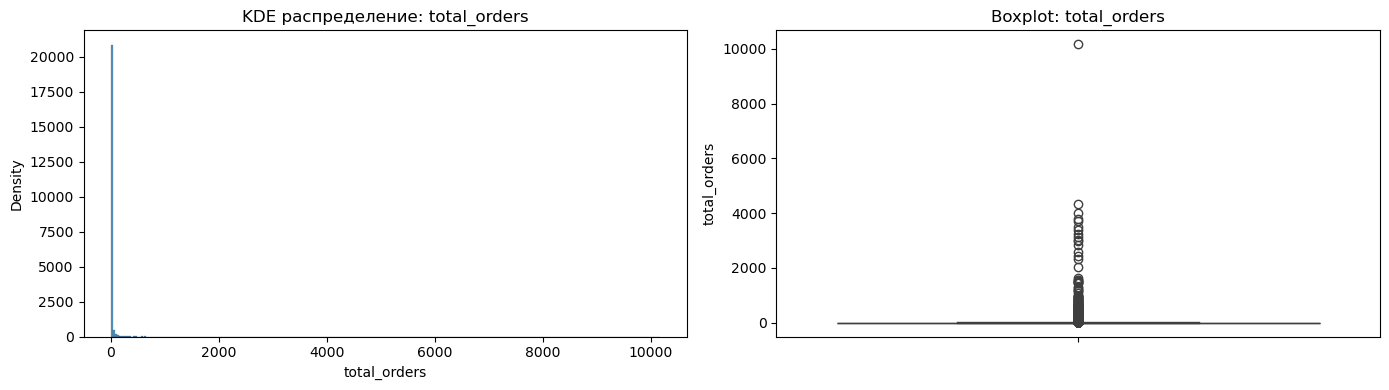

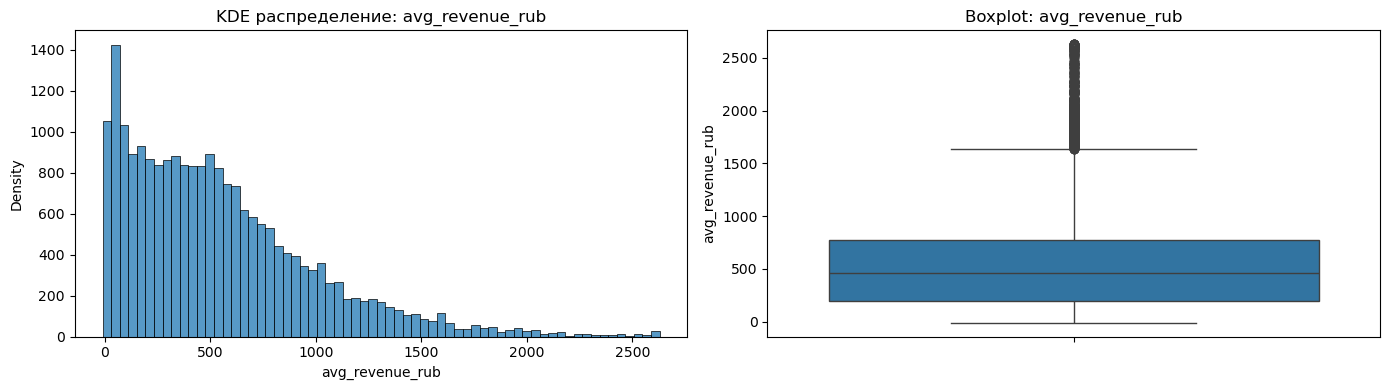

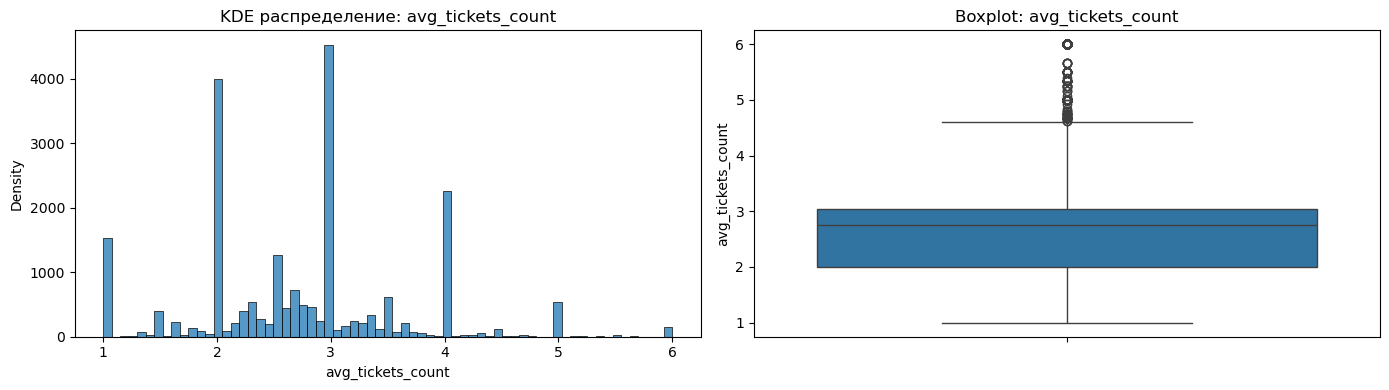

In [96]:
## Выводим boxplot и распределение числовых колонок
plot_numeric_kde_box(
    profiles,
    pr_num_cols
)

'total_orders' - очень большой разброс, диаграмма очень смещена влево. 75% - 5, max - 10168

По остальным колонкам: 'avg_revenue_rub', 'avg_tickets_count', нет сильных хвостов и выбросов


### Предобработка датасета Profiles


По total orders видим сильные выбросы, их стоит удалить, поскольку это могут быть либо фанаты, хотящие на определенные мероприятия, либо кто-то покупает билеты для корпоративных клиентов. Поэтому стоит подобрать перцентиль, чтобы убрать выбросы, но оставить большую часть датасета


In [97]:
# Подбираем перцентиль, и значений для удаления
check_outliers(profiles, ['total_orders'], percentile=0.97)


Колонка: total_orders
97-й перцентиль: 54.00
Количество значений выше: 651
Доля: 2.982%


In [98]:
## Вызов фильрации
percentiles = {
    'total_orders': 0.98
}

profiles = filter_by_percentiles(profiles, percentiles)

total_orders: порог 98% = 79.00

Исходный размер:   21,832
После фильтрации:  21,399
Удалено строк:     433 (1.98%)


In [99]:
# После преобразования оценим
profiles['total_orders'].describe()

count    21399.000000
mean         5.056545
std          9.497211
min          1.000000
25%          1.000000
50%          2.000000
75%          4.000000
max         79.000000
Name: total_orders, dtype: float64

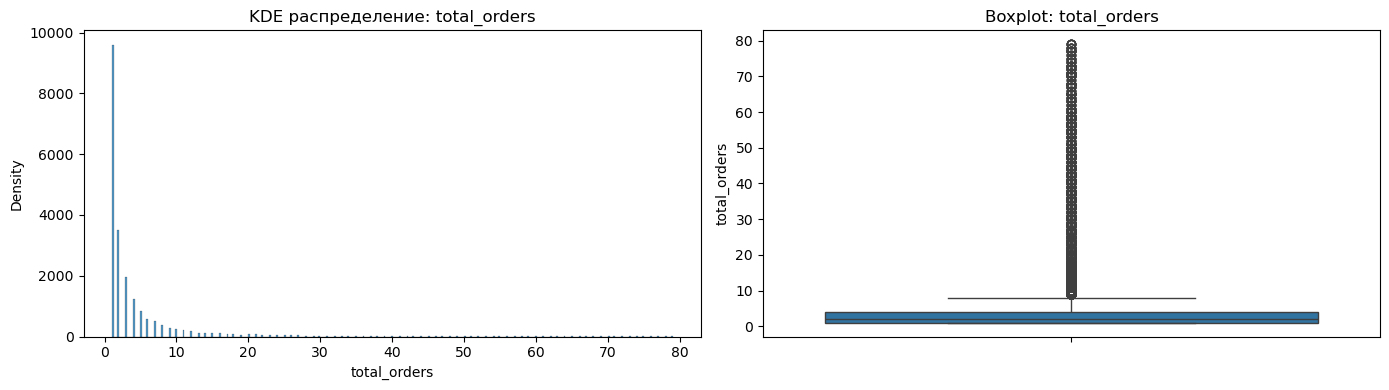

In [100]:
plot_numeric_kde_box(
    profiles,
    ['total_orders']
)

Гистрограмма все еще сильно смещена влево, но убирать больше пользователей не стоит. Может сильно повлиять на результат. Мы видим что основные пользователи от 1 до 14 билетов (по describe: median 5 + std 9.5), а Max - c 10168 опустилось до 79


## Результаты предобработки датасета Profiles

Создан новый df - `profiles` с уникальными пльзователями.

- 'first_order_dt' - дата первого заказа
- 'last_order_dt' - дата последнего заказа
- 'first_device' - устройство, с которого был сделан первый заказ
- 'first_region_name' - регион, в котором был сделан первый заказ
- 'first_service_name' - билетного партнёра, к которому обращались при первом заказе
- 'first_event_type' - жанр первого посещённого мероприятия (используйте поле event_type_main )
- 'total_orders' - общее количество заказов
- 'avg_revenue_rub' - средняя выручка с одного заказа в рублях
- 'avg_tickets_count' - среднее количество билетов в заказе
- 'avg_days_since_prev' - среднее время между заказами
- 'is_two' - совершил ли пользователь 2 и более заказа;
- 'is_five' - совершил ли пользователь 5 и более заказов.

Мы нашли выбросы по количеству заказов, удалили их по 98 перцентилю, но гистограмма все еще смещена влево. Это может быть связано с тем, что большинство пользователей покупают от 1 до 14 билетов.

Поэтому мы решили не удалять больше пользователей, чтобы не повлиять на результат анализа.

- Средняя выручка с одного заказа: 545.32 руб.
- Доля пользователей, совершивших 2 и более заказа: 0.56
- Доля пользователей, совершивших 5 и более заказа: 0.26
- Количество уникальных пользователей: 21399


## Исследовательский анализ данных

исследование признаков, влияющих на возврат пользователей, то есть на совершение повторного заказа.

### Исследование признаков первого заказа и их связи с возвращением на платформу